<a href="https://colab.research.google.com/github/margaretonatade-rgb/CUSTOMER-SEGMENTATION/blob/main/Copy_of_CUSTOMER_SEGMENTATION_GROUP_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Capstone Machine Learning Project
**Customer Segmentation Using K-Means Clustering**

### Course:
Machine Learning

### Date:
28th May 2026

### Group Members:
- RUTH
- TUNDE
- MUSA
- ROSELINE
- MELODY
- MAGARET
- PROMISE





## Introduction

Customer segmentation is just the process of grouping customers based on their income and spending behaviors..

In this project, we employed a machine learning method called K-Means clustering to analyze data on customer earnings and spending. The goal is to help businesses better understand their customers so they can create smarter, more effective marketing strategy.

## Project Objectives

The objectives of this project are:

- To analyze customer purchasing behavior
- To apply K-Means clustering for segmentation
- To identify different customer groups
- To visualize customer clusters
- To derive business insights from the data

## 1.Importing Required Libraries

The following libraries are used for:
- Data manipulation
- Data visualization
- Machine learning
- Data preprocessing

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



## Loading the Dataset

The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

##2. Load And Clean Dataset


In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# 3. Select Features

*Selected* the data we want to use which is Annual income and Spending score.

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


Annual income is high in value while spending is in lower value, which is why we are using scaling method.

#4. Scale

## Feature Scaling

Feature scaling is applied using StandardScaler to ensure that all features contribute equally to the clustering process.

Since K-Means groups customers by measuring the physical distance between them, it’s important that  annual income doesn't overshadow the spending score just because the numbers happen to be larger.
Scaling keeps everything balanced so the groups are much more accurate.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Elbow Method

## Determining the Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters (K).

The method calculates the Within-Cluster Sum of Squares (WCSS) for different values of K and identifies the point where the reduction in WCSS becomes smaller.



## To determine the number of clusters, which is called 'K'
Code gotten from the help of chatgpt



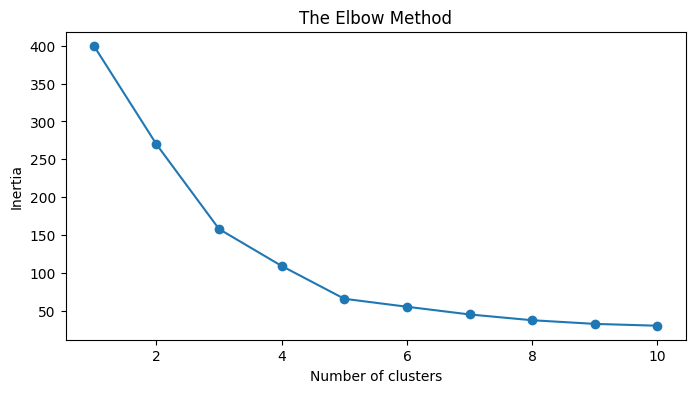

In [ ]:
inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# 6. Training The Model

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster']

,Cluster
0,4
1,2
2,4
3,2
4,4
...,...
195,1
196,3
197,1
198,3


##7. Centroids
To visualize the centers of the clusters.

Code gotten from the help of chatgpt.


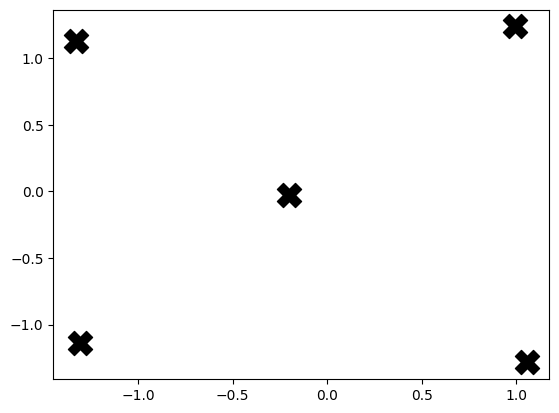

In [ ]:
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='black', marker='X', label='Centroids')

#8. Visualize

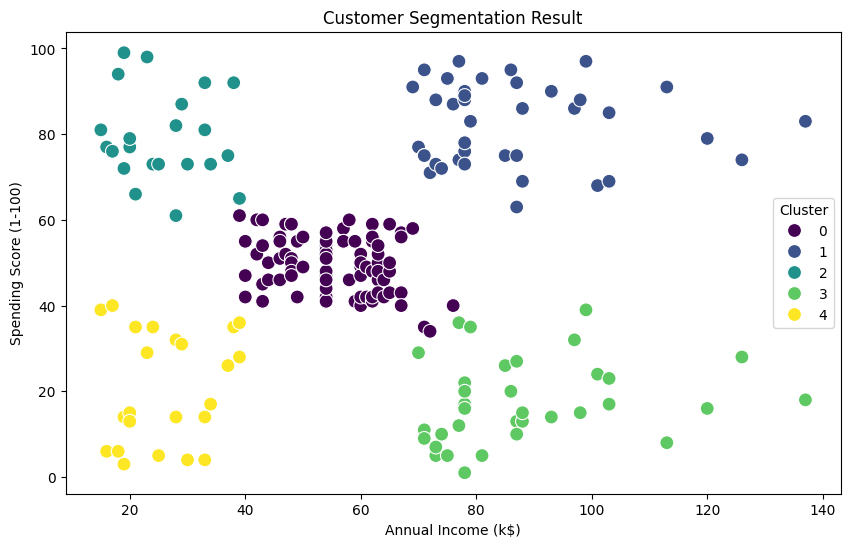

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df, palette='viridis', s=100)
plt.title('Customer Segmentation Result')
plt.show()

#The visualization revealed:


high-income high-spending customers

high-income low-spending customers


low-income high-spending customers


low-income low-spending customers


and average customers











#9. Cluster Analysis
 Print the average income and spending for each cluster

In [ ]:
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


## Results and Interpretation

The model successfully identified distinct customer segments.

The clusters reveal differences in:
- Customer income
- Spending patterns
- Purchasing behavior

These insights can help businesses develop targeted marketing strategies.

## Business Recommendations

The customer segments identified through K-Means clustering can support targeted marketing strategies.

For example:
- High-income high-spending customers can be targeted with loyalty programs and premium offers.
- High-income low-spending customers may respond to personalized promotions.
- Low-income high-spending customers can be targeted with discounts and affordable packages.
- Average customers can be engaged through seasonal campaigns and referral programs.

These strategies can help businesses improve customer satisfaction and increase sales.

In [ ]:
from sklearn.cluster import KMeans